# 01 — Data Exploration

In [2]:
import os
if not os.path.exists('MiniGPT'):
    !git clone https://github.com/userKk1/MiniGPT.git
%cd MiniGPT

Cloning into 'MiniGPT'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 79 (delta 32), reused 46 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 107.61 KiB | 3.07 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/MiniGPT


In [3]:
!pip install -q datasets matplotlib

In [4]:
import sys
sys.path.append('.')

from config import cfg, DATA_RAW_DIR
from datasets import load_dataset
import matplotlib.pyplot as plt

print(cfg.data)

DataConfig(dataset_name='codeparrot/codeparrot-clean', max_corpus_mb=20, max_file_chars=20000, train_split=0.9, seed=1337)


## 1. Stream the dataset

In [5]:
ds = load_dataset(
    "codeparrot/codeparrot-clean",
    split="train",
    streaming=True,
).shuffle(seed=cfg.data.seed, buffer_size=10_000)



samples = []
total_bytes = 0
TARGET_BYTES = cfg.data.max_corpus_mb * 1024 * 1024

for example in ds:
    content = example.get('content', '')
    if not content:
        continue
    if example.get("autogenerated", False):
        continue
    if len(content) > cfg.data.max_file_chars:
        continue
    if not content.isascii():
        continue

    samples.append(content)
    total_bytes += len(content.encode("utf-8"))
    if total_bytes >= TARGET_BYTES:
        break

print(f'Collected {len(samples)} files, {total_bytes / (1024 * 1024):.2f} MB')

README.md:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/54 [00:00<?, ?it/s]

Collected 4138 files, 20.00 MB


## 2. Look at file length distribution

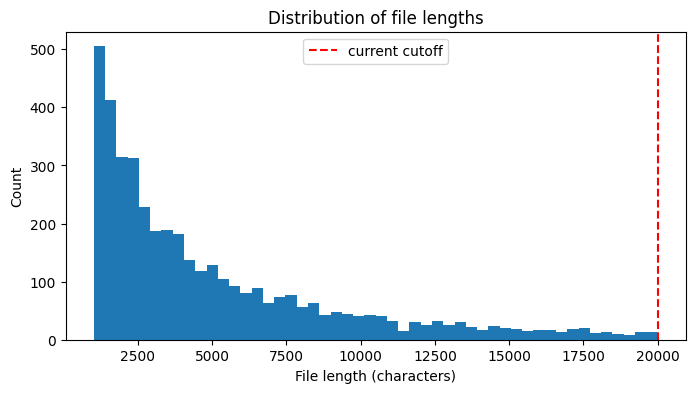

median: 3513
max: 19989
files above cutoff: 0 / 4138


In [6]:
lengths = [len(s) for s in samples]

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50)
plt.xlabel('File length (characters)')
plt.ylabel('Count')
plt.title('Distribution of file lengths')
plt.axvline(cfg.data.max_file_chars, color='red', linestyle='--', label='current cutoff')
plt.legend()
plt.show()

print('median:', sorted(lengths)[len(lengths)//2])
print('max:', max(lengths))
print(f'files above cutoff: {sum(l > cfg.data.max_file_chars for l in lengths)} / {len(lengths)}')

In [7]:
for s in samples[:3]:
    print(s[:400])
    print('-' * 60)

#!/usr/bin/env python
# vim: tabstop=4 shiftwidth=4 softtabstop=4
#
# Copyright (c) 2012 Rackspace Hosting
# All Rights Reserved.
#
#    Licensed under the Apache License, Version 2.0 (the "License"); you may
#    not use this file except in compliance with the License. You may obtain
#    a copy of the License at
#
#         http://www.apache.org/licenses/LICENSE-2.0
#
#    Unless required by app
------------------------------------------------------------
#!/usr/bin/env python
#-------------------------------------------------------------------------------
#    FILE: gentankdiy.py
# PURPOSE: gentankdiy.py add enhanced external tank data to genmon
#
#  AUTHOR: jgyates
#    DATE: 06-18-2019
#
# MODIFICATIONS:
#-------------------------------------------------------------------------------


import datetime, time, sys, signal, os, threading, collectio
------------------------------------------------------------
# -*- coding: utf-8 -*-
from operator import attrgetter
from pyangbind.lib.y

## 4. Character vocabulary

In [8]:
corpus_sample = ''.join(samples)
chars = sorted(set(corpus_sample))
print(f'Vocab size: {len(chars)}')
print(''.join(chars))

Vocab size: 100
	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~


In [9]:
from collections import Counter

char_counts = Counter(corpus_sample)

print("Total unique characters:", len(char_counts))

print("\nTop 50:")
for char, count in char_counts.most_common(50):
    print(repr(char), count)

Total unique characters: 100

Top 50:
' ' 4809990
'e' 1492989
't' 1042203
's' 890774
'r' 832364
'a' 819374
'i' 779015
'o' 755899
'n' 724034
'\n' 605052
'l' 588319
'd' 449157
'c' 404299
'p' 396757
'_' 387856
'f' 375134
'm' 354327
'.' 348969
'u' 344336
')' 262250
'(' 262211
',' 252264
"'" 245491
'g' 228827
'h' 224777
'=' 217382
'"' 187458
':' 155873
'b' 148297
'y' 141594
'#' 119837
'v' 107595
'-' 105924
'w' 99600
'x' 96179
'0' 91825
'k' 84346
'T' 80413
'E' 69056
'[' 66984
']' 66903
'S' 63431
'1' 62307
'A' 56606
'N' 55267
'I' 53891
'R' 50722
'\t' 49731
'C' 49707
'2' 41906


In [10]:
total = sum(char_counts.values())

for threshold in [1, 2, 5, 10, 50, 100, 1000]:
    rare = sum(
        count <= threshold
        for count in char_counts.values()
    )

    print(
        f"Characters appearing <= {threshold} times: "
        f"{rare} / {len(char_counts)}"
    )

Characters appearing <= 1 times: 1 / 100
Characters appearing <= 2 times: 1 / 100
Characters appearing <= 5 times: 1 / 100
Characters appearing <= 10 times: 2 / 100
Characters appearing <= 50 times: 2 / 100
Characters appearing <= 100 times: 2 / 100
Characters appearing <= 1000 times: 2 / 100
